In [27]:
#file has prefix,sample_id,mode,model_config,model_type,checkpoint,dhs_dataset,result_np
import pandas as pd
results_df=pd.read_table("/net/seq/data2/projects/ENCODE4Plus/REGULOME/sequence_to_accessibility_model/vinson_model/2025_11_04_trusting_goldwasser/predictions/output/per_sample_predictions_meta.w_checkpoint.annotated_with_predictions.tsv")

In [394]:
import anndata as ad
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import argparse
import scipy

from genome_tools.data.anndata import read_zarr_backed

from vinson.utils.data_formatting import extract_data_from_h5
from vinson.utils.helpers import read_configs
from vinson.postprocessing.plotting.per_dhs import obs_pred_barplot_by_ann, scatter_by_ann_train_val, aggregate_eval_dataset_by_sample
from vinson.postprocessing.utils import annotate_eval_dataset_with_layers, annotate_eval_dataset_with_obs_columns, calculate_per_dhs_fold_changes, get_samples_used_in_training_for_dhs
#from vinson.postprocessing.metrics import calc_metrics


In [37]:
###individually pull out training and validation regions

In [ ]:
#add bar for cancer and 

In [2]:
import anndata as ad

adata = ad.read_h5ad('/net/seq/data2/projects/ENCODE4Plus/REGULOME/sequence_to_accessibility_model/training_data/NOV03/NOV03_3_epochs_with_weights_fc_squared_50.h5ad')



KeyboardInterrupt



In [ ]:
adata.obsm["split_data"][:10]

In [52]:
# -----------------------------------------
# 2. Extract split_data and convert index → column
# -----------------------------------------
split_data = adata.obsm["split_data"]

# Make a DataFrame with index (sample_id) + split_data
split_df = pd.DataFrame(split_data, index=adata.obs.index).copy()
split_df["sample_id"] = split_df.index

# -----------------------------------------
# 4. Merge: sample_id (pearson) ↔ sample_id (AnnData index)
# -----------------------------------------
merged_df = pearson_results_df.merge(
    split_df,
    on="sample_id",
    how="left"
)


In [53]:
merged_df

,prefix,sample_id,mode,model_config,model_type,checkpoint,dhs_dataset,result_np,pearson,r2,0
0,AG10697_sample_dhs,AG10697,sample_dhs,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,vinson,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,0.877167,0.769422,val
1,AG12379_sample_dhs,AG12379,sample_dhs,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,vinson,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,0.837814,0.701932,train
2,AG15858_sample_dhs,AG15858,sample_dhs,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,vinson,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,0.764802,0.584922,train
3,AG3830_sample_dhs,AG3830,sample_dhs,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,vinson,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,0.829412,0.687924,train
4,AG3832_sample_dhs,AG3832,sample_dhs,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,vinson,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,0.888048,0.788629,train
...,...,...,...,...,...,...,...,...,...,...,...
2068,AG93421_sample_dhs,AG93421,sample_dhs,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,vinson,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,0.813184,0.661269,train
2069,AG93505_sample_dhs,AG93505,sample_dhs,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,vinson,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,0.821621,0.675061,train
2070,AG93570_sample_dhs,AG93570,sample_dhs,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,vinson,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,0.879019,0.772674,train
2071,AG93493_sample_dhs,AG93493,sample_dhs,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,vinson,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/s...,0.814791,0.663884,train


Means:
 0
test     0.828014
train    0.835336
val      0.832026
Name: pearson, dtype: float64
Stds:
 0
test     0.064923
train    0.055604
val      0.068975
Name: pearson, dtype: float64
Counts:
 0
test       50
train    1973
val        50
Name: pearson, dtype: int64


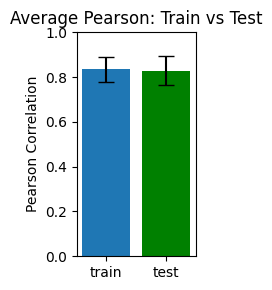

In [82]:
import pandas as pd
import matplotlib.pyplot as plt

# merged_df is already loaded
df = merged_df.copy()

# --------------------------------------
# 1. Compute means, std, and counts for each split
# --------------------------------------
grouped = df.groupby(0)["pearson"]  # 0 column contains split_data (train/val)

means = grouped.mean()
stds = grouped.std()
counts = grouped.count()

print("Means:\n", means)
print("Stds:\n", stds)
print("Counts:\n", counts)

# Ensure consistent bar order
labels = ["train", "test"]
values = [means.get("train", float("nan")), means.get("test", float("nan"))]
errors = [stds.get("train", 0), stds.get("test", 0)]
counts_values = [counts.get("train", 0), counts.get("test", 0)]

# --------------------------------------
# 2. Set colors (green for test/validation)
# --------------------------------------
colors = ["tab:blue", "green"]

# --------------------------------------
# 3. Make bar plot with skinnier bars
# --------------------------------------
fig, ax = plt.subplots(figsize=(2,3))

bars = ax.bar(labels, values, yerr=errors, color=colors, capsize=6)

ax.set_ylabel("Pearson Correlation")
ax.set_title("Average Pearson: Train vs Test")
ax.set_ylim(0, 1)

plt.tight_layout()  # ensures labels fit
plt.savefig("pearson_train_vs_test.pdf")

